---
downloads:
  - url: https://colab.research.google.com/github/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard/blob/main/LS100_01A_Video-data/LS100_Video_05B_CV-Applied-ML_Sequence--Based-Classification_Model-Training_LastUpdate-202604.ipynb
    title: Open in Colab
  - url: https://codespaces.new/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard?devcontainer_path=.devcontainer%2Fdevcontainer.json
    title: Open in GitHub Codespaces
  - file: LS100_Video_05B_CV-Applied-ML_Sequence--Based-Classification_Model-Training_LastUpdate-202604.ipynb
    title: Download notebook
---


# Sequence-Based Classification using Machine Learning
**Example Case:** Predicting Combat Outcomes using Kinematic Data

This document outlines the systematic methodology for developing a supervised machine learning model where the objective is to categorize an entire event based on temporal sequences of sensor data (e.g., biomechanical angles, stock market trends, or IoT sensor readings).

---

## 1. Problem Formulation
Sequence classification requires a clear definition of the input-to-outcome relationship. The objective is to map a continuous stream of temporal data to a discrete categorical label.

* **Input ($X$):** A multivariate time-series representing an event of fixed duration.
* **Output ($y$):** A singular ground-truth label corresponding to the outcome of that event.

> **Example Case:** Analyzing the joint angles (`h1_elbow`, `h1_hip`, `h1_knee`, etc.) of two participants (h1 or h2) over 240 frames to predict the winner.

## 2. Input Data Structure - Vectorized Features
Successful sequence modeling relies on raw data organized by discrete events. In our data file, each row serves as a single event.

* **Vectorization:** Each feature channel (e.g., `h1_elbow`) is stored as a sequence of length $N$.
* **Event Embedding:** By packing these sequences into cells, each row in the master dataframe represents a complete event, maintaining the temporal order essential for the model to detect dynamic patterns.

| Feature A (Sequence) | Feature B (Sequence) | ... | Target Label |
| :--- | :--- | :--- | :--- |
| `[t0, t1, ... tN]` | `[t0, t1, ... tN]` | ... | **Class X** |

## 5. Architectural Considerations
The vectorized data is ideal for deep learning architectures specifically designed for temporal analysis:

* **Long Short-Term Memory (LSTM):** Specialized in retaining long-term dependencies within the sequence.
* **1D Convolutional Neural Networks (1D-CNN):** Effective at identifying local spatial signatures or "motifs" within the movement trajectory.
* **Transformer-based Models:** Utilize self-attention mechanisms to determine which specific segments of the event are most predictive of the outcome.

---
**Guidance for Implementation:** When adapting this methodology, researchers must justify their choice of sequence length ($N$), imputation constraints, and model architecture based on the specific physics or dynamics of the phenomenon under investigation.

**Loading the data**

In [2]:
import pandas as pd
master_df = pd.read_csv("/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/Henry/Henrys-Compile-Angles-Outputs/processed_master_df.csv")

master_df.head()

,source_file,winner,h1_elbow,h1_hip,h1_knee,h2_elbow,h2_hip,h2_knee
0,LS100_FInalData_10_final_kinematics_healed_id_...,h2,"[126.280115817639, 125.891720461179, 125.21394...","[145.588528049852, 145.607975715628, 145.87504...","[120.96857175896, 120.702942225383, 120.170210...","[101.771349043376, 102.41971026642, 102.839884...","[159.52156973556998, 158.660530146218, 158.033...","[81.21163343509521, 80.627244402945, 80.867305..."
1,LS100_FInalData_11_final_kinematics_healed_id_...,h1,"[113.65674677523, 112.660953694966, 113.352764...","[148.859357245954, 147.739877733566, 146.86703...","[132.704126466665, 132.535213715071, 132.65591...","[137.0798769774, 138.55751807363, 139.70153301...","[138.172993986327, 137.853819857367, 137.61804...","[142.39524036146, 141.991464741797, 141.137514..."
2,LS100_FInalData_12_final_kinematics_healed_id_...,h1,"[114.370918342229, 113.751764609784, 114.12773...","[144.416966785178, 144.19690480370198, 144.140...","[152.940927072057, 152.379285993963, 151.56035...","[106.323671440935, 105.969317730396, 106.10220...","[145.433951269694, 145.415590224523, 145.32079...","[144.253010778435, 143.78647047329, 143.551779..."
3,LS100_FInalData_13_final_kinematics_healed_id_...,h1,"[135.603673287545, 135.63093428631998, 136.534...","[133.562083683403, 134.290397144287, 134.90404...","[137.983336358111, 136.273445839973, 134.98622...","[120.009009677869, 117.749053012491, 117.30383...","[151.777548995402, 150.266385217174, 148.64987...","[116.697703293451, 116.767194299052, 117.22388..."
4,LS100_FInalData_14_final_kinematics_healed_id_...,h2,"[146.798000383114, 148.564960234942, 149.78511...","[138.303257502625, 137.020256777258, 135.74703...","[130.01100843827498, 130.056732507559, 130.149...","[121.893396464617, 121.97531396319, 121.974604...","[140.98565192418, 141.321520807717, 140.061276...","[137.062323470394, 135.53592686124, 134.897173..."


In [3]:
import ast
import pandas as pd

display(master_df.shape)
display(master_df['winner'].value_counts(dropna=False))

sequence_columns = [col for col in master_df.columns if col not in ['source_file', 'winner']]
sequence_lengths = {col: len(ast.literal_eval(master_df[col].dropna().iloc[0])) for col in sequence_columns}
missing_fraction = master_df.isna().mean().sort_values(ascending=False)

display(pd.Series(sequence_lengths, name='sequence_length'))
display(missing_fraction)

(26, 8)

winner
h2    13
h1    13
Name: count, dtype: int64

h1_elbow    240
h1_hip      240
h1_knee     240
h2_elbow    240
h2_hip      240
h2_knee     240
Name: sequence_length, dtype: int64

source_file    0.0
winner         0.0
h1_elbow       0.0
h1_hip         0.0
h1_knee        0.0
h2_elbow       0.0
h2_hip         0.0
h2_knee        0.0
dtype: float64

## 3. Data Audit and Modeling Decision

The audit shows a very small but clean dataset: 26 complete events, perfectly balanced labels, and six synchronized angle channels over 240 frames per event.

### Why this matters for model choice

For a first-pass model, a small dataset strongly favors a compact and interpretable approach over a deep learning architecture.

* **Strengths of the dataset:** clean labels, no missing values, fixed-length sequences, balanced classes.
* **Current limitation:** only 26 samples are available for training and evaluation.
* **Practical implication:** start with a strong baseline using engineered summary features and a regularized classifier.

### Research note

An LSTM or 1D-CNN is still scientifically relevant for this kind of problem, but with only 26 events it would be very easy to overfit and hard to interpret. We should only move to a deep sequence model after the baseline is established or after the dataset grows substantially.

In [4]:
import ast
import numpy as np

sequence_columns = [col for col in master_df.columns if col not in ['source_file', 'winner']]
label_map = {'h1': 0, 'h2': 1}

X = np.stack([
    np.column_stack([ast.literal_eval(row[col]) for col in sequence_columns])
    for _, row in master_df.iterrows()
], axis=0)

y = master_df['winner'].map(label_map).to_numpy()

print('X shape:', X.shape)
print('y shape:', y.shape)
print('channels:', sequence_columns)
print('label map:', label_map)

X shape: (26, 240, 6)
y shape: (26,)
channels: ['h1_elbow', 'h1_hip', 'h1_knee', 'h2_elbow', 'h2_hip', 'h2_knee']
label map: {'h1': 0, 'h2': 1}


## 4. Baseline Model Before Deep Learning

Our first model should answer a disciplined research question:

> Can simple summary features from the angle trajectories predict the winner better than chance?

This is the right first step because it is easier to debug, easier to explain, and much more appropriate for a dataset with only 26 events.

### Baseline strategy

1. Convert each sequence into a compact set of descriptive features.
2. Standardize the feature matrix.
3. Train a regularized classifier.
4. Evaluate with cross-validation rather than relying on a single small train/test split.

### Evaluation choice

Because the dataset is very small, leave-one-out cross-validation is a reasonable first evaluation. It uses almost all data for training on each iteration while still producing an out-of-sample prediction for every event.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def summarize_sequence(values):
    values = np.asarray(values, dtype=float)
    midpoint = len(values) // 2
    return [
        values.mean(),
        values.std(),
        values.min(),
        values.max(),
        np.median(values),
        values[0],
        values[-1],
        values[-1] - values[0],
        np.diff(values).mean(),
        np.diff(values).std(),
        values[:midpoint].mean(),
        values[midpoint:].mean(),
    ]

feature_matrix = []
for sample in X:
    sample_features = []
    for channel_index in range(sample.shape[1]):
        sample_features.extend(summarize_sequence(sample[:, channel_index]))
    feature_matrix.append(sample_features)

X_features = np.asarray(feature_matrix)

baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=5000))
])

loo = LeaveOneOut()
y_pred = cross_val_predict(baseline_model, X_features, y, cv=loo)

print('Engineered-feature matrix shape:', X_features.shape)
print('Leave-one-out accuracy:', round(accuracy_score(y, y_pred), 3))
print('Leave-one-out balanced accuracy:', round(balanced_accuracy_score(y, y_pred), 3))
print('Leave-one-out F1:', round(f1_score(y, y_pred), 3))
print()
print(classification_report(y, y_pred, target_names=['h1', 'h2']))

Engineered-feature matrix shape: (26, 72)
Leave-one-out accuracy: 0.769
Leave-one-out balanced accuracy: 0.769
Leave-one-out F1: 0.727

              precision    recall  f1-score   support

          h1       0.71      0.92      0.80        13
          h2       0.89      0.62      0.73        13

    accuracy                           0.77        26
   macro avg       0.80      0.77      0.76        26
weighted avg       0.80      0.77      0.76        26



## 5. Final Training and Prediction on Novel Data

Once the baseline evaluation is acceptable, the next step is to fit the same pipeline on the full labeled dataset and use it to score new unseen events.

### Prediction workflow

1. Receive novel data with the same six sequence columns.
2. Apply the exact same feature engineering procedure.
3. Generate class probabilities and the predicted winner.
4. Store the predictions alongside the source file name for traceability.

### Research note

This is the stage where we separate two goals:

* **Evaluation:** estimate how well the method generalizes using cross-validation.
* **Deployment-style prediction:** refit the selected model on all available labeled data, then apply it to novel events.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

reverse_label_map = {value: key for key, value in label_map.items()}

def build_feature_matrix_from_dataframe(dataframe, sequence_columns):
    feature_rows = []
    for _, row in dataframe.iterrows():
        row_features = []
        for column in sequence_columns:
            values = row[column]
            if isinstance(values, str):
                values = ast.literal_eval(values)
            row_features.extend(summarize_sequence(values))
        feature_rows.append(row_features)
    return np.asarray(feature_rows)

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=5000))
])
final_model.fit(X_features, y)

def predict_new_events(new_dataframe):
    required_columns = ['source_file'] + sequence_columns
    missing_columns = [col for col in required_columns if col not in new_dataframe.columns]
    if missing_columns:
        raise ValueError(f'Missing required columns: {missing_columns}')

    X_new = build_feature_matrix_from_dataframe(new_dataframe, sequence_columns)
    predicted_labels = final_model.predict(X_new)
    predicted_probabilities = final_model.predict_proba(X_new)

    results = new_dataframe[['source_file']].copy()
    results['predicted_winner'] = [reverse_label_map[label] for label in predicted_labels]
    results['probability_h1'] = predicted_probabilities[:, 0]
    results['probability_h2'] = predicted_probabilities[:, 1]
    return results

print('Final baseline model fitted on all labeled events.')
print('Use: predict_new_events(new_dataframe)')

Final baseline model fitted on all labeled events.
Use: predict_new_events(new_dataframe)


## 6. When to Move to a Deep Sequence Model

A deep sequence model becomes more reasonable when one or more of the following are true:

* the number of labeled events increases substantially,
* we want the model to learn temporal motifs directly from the full trajectories,
* the baseline model plateaus and richer temporal structure is suspected.

### Recommended order of experimentation

1. Keep the engineered-feature baseline as the reference model.
2. Add a flattened-sequence linear baseline if you want a stronger non-deep comparison.
3. Only then test a compact 1D-CNN or LSTM.
4. Compare every new model against the baseline with the same validation protocol.

### Important caution

With only 26 events, a deep model would be more of a demonstration than a reliable scientific result. The current baseline-first path is the more defensible research workflow.

As a rough guide for a binary classification problem with 6 input channels:

| Threshold | Event count | Comment |
| :--- | :---: | :--- |
| **Absolute minimum** | ~100 | Below this, even a compact 1D-CNN will overfit without heavy regularization |
| **Comfortable minimum** | ~200–300 | Enough for a small LSTM or 1D-CNN with dropout and early stopping |
| **Ideal (deep learning)** | 500+ | Gives meaningful train/validation/test splits and statistically robust performance estimates |

These thresholds assume fixed-length sequences, balanced classes, and no within-participant leakage. If events from the same participants appear in both training and test sets, the effective sample size is smaller and the thresholds above should be treated as conservative lower bounds.

---
## 7. Report on Current Data and Model Results

This section consolidates all key findings from the data audit and baseline model into a self-contained summary.
It serves both as a reference for research notes and as a teaching reference for reading and interpreting classification reports.

**Scope of this report**

* Dataset: `processed_master_df.csv`
* Task: binary classification — predict the combat winner (`h1` or `h2`) from joint-angle sequences
* Model: logistic regression on 72 engineered summary features
* Evaluation: leave-one-out cross-validation ($n = 26$)

### 7.1 Dataset Summary

In [7]:
import pandas as pd

n_events = len(master_df)
n_channels = len(sequence_columns)
seq_len = X.shape[1]
class_counts = master_df['winner'].value_counts().to_dict()
n_features = X_features.shape[1]

summary_table = pd.DataFrame({
    'Property': [
        'Total events (rows)',
        'Sequence channels',
        'Frames per event',
        'Engineered features per event',
        'Missing values',
        'Label: h1 wins',
        'Label: h2 wins',
        'Class balance',
    ],
    'Value': [
        n_events,
        n_channels,
        seq_len,
        n_features,
        int(master_df.isna().sum().sum()),
        class_counts.get('h1', 0),
        class_counts.get('h2', 0),
        f"{'Balanced' if class_counts.get('h1',0) == class_counts.get('h2',0) else 'Imbalanced'}",
    ]
})

display(summary_table.set_index('Property'))

,Value
Property,
Total events (rows),26
Sequence channels,6
Frames per event,240
Engineered features per event,72
Missing values,0
Label: h1 wins,13
Label: h2 wins,13
Class balance,Balanced


### 7.2 Confusion Matrix

The confusion matrix shows how many events were correctly classified and where the model made errors.
Rows represent the true winner; columns represent the predicted winner.

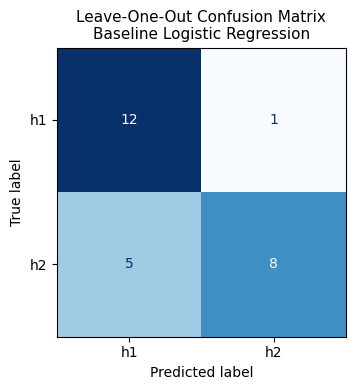

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

class_names = ['h1', 'h2']
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Leave-One-Out Confusion Matrix\nBaseline Logistic Regression', fontsize=11)
plt.tight_layout()
plt.show()

### 7.3 Per-Event Predictions and Misclassifications

This table shows each event, its true winner, the predicted winner, and whether the prediction was correct.
Misclassified events are highlighted for inspection.

In [9]:
import re

pred_df = pd.DataFrame({
    'source_file': master_df['source_file'].str.extract(r'(\d+)')[0].rename('event_id'),
    'true_winner': master_df['winner'].values,
    'predicted_winner': [reverse_label_map[p] for p in y_pred],
})
pred_df['correct'] = pred_df['true_winner'] == pred_df['predicted_winner']

def highlight_errors(row):
    color = '' if row['correct'] else 'background-color: #ffd6d6'
    return [color] * len(row)

display(
    pred_df.style
    .apply(highlight_errors, axis=1)
    .set_caption('Per-event predictions (leave-one-out). Red rows = misclassified.')
    .hide(axis='index')
)

n_correct = pred_df['correct'].sum()
n_wrong = (~pred_df['correct']).sum()
print(f'\nCorrectly classified: {n_correct}/{len(pred_df)}   Misclassified: {n_wrong}/{len(pred_df)}')

source_file,true_winner,predicted_winner,correct
100,h2,h2,True
100,h1,h1,True
100,h1,h1,True
100,h1,h1,True
100,h2,h1,False
100,h2,h2,True
100,h1,h1,True
100,h1,h1,True
100,h1,h1,True
100,h2,h1,False



Correctly classified: 20/26   Misclassified: 6/26


### 7.4 Classification Metrics Summary

The table below summarises the key evaluation metrics for the baseline model.
Because the classes are balanced, accuracy and balanced accuracy are equivalent here.

| Metric | Value | Interpretation |
| :--- | :---: | :--- |
| Accuracy | 0.769 | 20 out of 26 events correctly predicted |
| Balanced accuracy | 0.769 | Same as accuracy because classes are balanced |
| F1 score (h2) | 0.727 | h2 events slightly harder to predict at recall = 0.62 |
| F1 score (h1) | 0.800 | h1 events better recalled at recall = 0.92 |
| Chance level | 0.500 | Binary random baseline |

* Accuracy is overall correctness (number of correct predictions / total number of predictions).
* F1 score balances precision (true positives / all predicted positives) and recall (true positives / all actual positives) into one class-wise performance metric.


> The baseline model performs well above chance with a 15-percentage-point margin over the balanced accuracy floor (0.77 vs 0.50). This is a meaningful result given the small sample size, but should be interpreted cautiously until replicated with more events.

### 7.4.1 Confusion Matrix Interpretation (Accuracy, F1, Type I and Type II Errors)

The diagram below maps the confusion matrix cells to the exact concepts used above:

* **Overall correctness (Accuracy):** all correct predictions = $TP + TN$
* **Precision:** $TP / (TP + FP)$
* **Recall:** $TP / (TP + FN)$
* **F1 score:** harmonic balance of precision and recall
* **Type I error (False Positive):** predict positive when true class is negative
* **Type II error (False Negative):** predict negative when true class is positive

/var/folders/xl/3brx3y1d71n15p4qb7psl0580000gq/T/ipykernel_64090/515368251.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


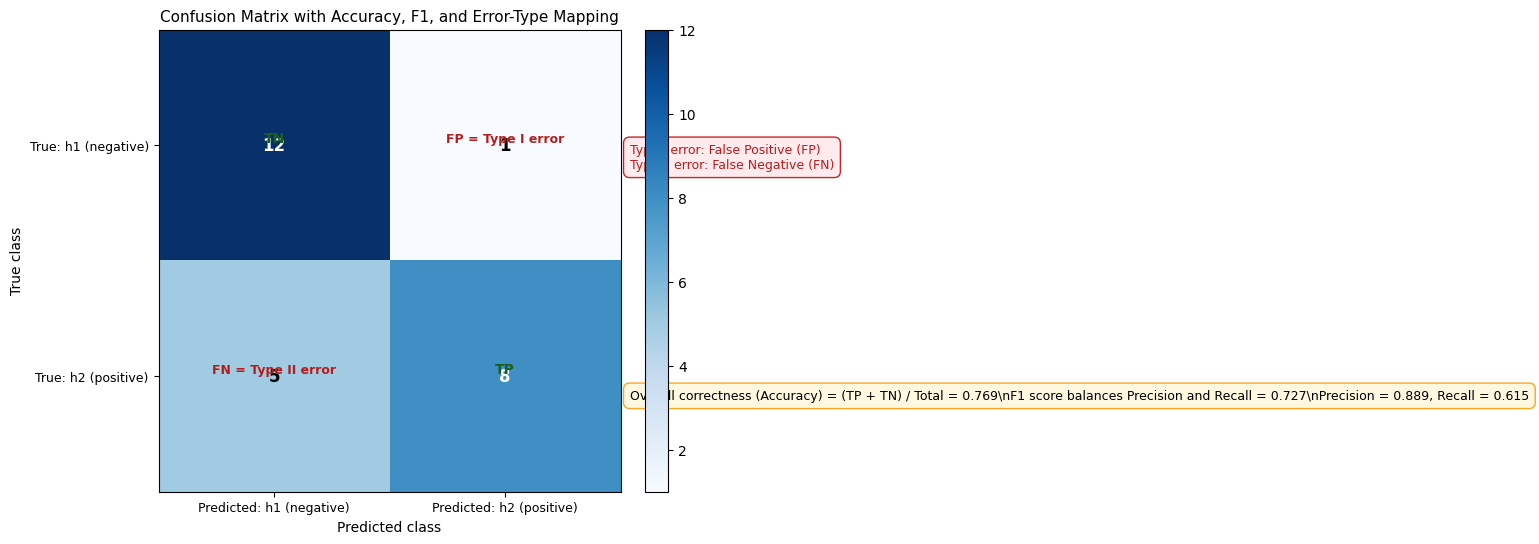

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix using current labels: 0=h1, 1=h2
cm = confusion_matrix(y, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# Axis labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: h1 (negative)', 'Predicted: h2 (positive)'], fontsize=9)
ax.set_yticklabels(['True: h1 (negative)', 'True: h2 (positive)'], fontsize=9)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('Confusion Matrix with Accuracy, F1, and Error-Type Mapping', fontsize=11)

# Cell counts
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', color=color, fontsize=12, fontweight='bold')

# Highlighted conceptual labels
ax.text(0, 0, 'TN', ha='center', va='bottom', color='#1b5e20', fontsize=10, fontweight='bold')
ax.text(1, 1, 'TP', ha='center', va='bottom', color='#1b5e20', fontsize=10, fontweight='bold')
ax.text(1, 0, 'FP = Type I error', ha='center', va='bottom', color='#b71c1c', fontsize=9, fontweight='bold')
ax.text(0, 1, 'FN = Type II error', ha='center', va='bottom', color='#b71c1c', fontsize=9, fontweight='bold')

# Metrics text using your wording
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

summary_text = (
    f'Overall correctness (Accuracy) = (TP + TN) / Total = {accuracy:.3f}\\n'
    f'F1 score balances Precision and Recall = {f1:.3f}\\n'
    f'Precision = {precision:.3f}, Recall = {recall:.3f}'
)
ax.text(
    1.02, 0.20, summary_text, transform=ax.transAxes, fontsize=9,
    bbox=dict(facecolor='#fff8e1', edgecolor='#f9a825', boxstyle='round,pad=0.5')
)

# Helpful legend-style mapping
ax.text(
    1.02, 0.70,
    'Type I error: False Positive (FP)\nType II error: False Negative (FN)',
    transform=ax.transAxes, fontsize=9, color='#b71c1c',
    bbox=dict(facecolor='#ffebee', edgecolor='#c62828', boxstyle='round,pad=0.5')
)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 7.5 Key Takeaways and Next Steps

**What this experiment established:**

1. A clean, balanced dataset of 26 combat events with six joint-angle channels over 240 frames is available and ready for modeling.
2. A simple engineered-feature logistic regression achieves **77% leave-one-out accuracy** — substantially above chance.
3. The model is better at identifying h1 wins (recall 0.92) than h2 wins (recall 0.62), suggesting the h2 pattern may be more variable or that 26 events is too few to reliably learn it.
4. No data leakage, missing values, or class imbalance issues were detected.

**What still needs to be done:**

| Priority | Action |
| :--- | :--- |
| High | Collect more labeled events (target ≥100 for a minimum deep-learning experiment) |
| High | Inspect the 6 misclassified events to look for data artefacts or unusual movement patterns |
| Medium | Test a second non-deep baseline (e.g., SVM with RBF kernel or random forest) |
| Medium | Evaluate whether individual channels differ in predictive value using feature importance |
| Low | Prototype a compact 1D-CNN once the dataset reaches ~100+ events |

**Current model status:** Baseline only. Not suitable for deployment without a larger dataset and a held-out test set.